# 02 — Engineered Feature Validation

Validates the features produced by `src/features/feature_pipeline.py` against `data/processed/model_dataset.parquet`.

This notebook is **not general EDA** (see `01_data_exploration.ipynb` for that).  
The goal here is to confirm:

1. **Completeness** — expected null patterns, no surprise gaps
2. **Rolling feature correctness** — Week-1 nulls per season, temporal ordering, no leakage
3. **Value sanity** — plausible ranges, no runaway outliers from the rolling window
4. **Signal strength** — do the engineered features actually correlate with `yards_gained` beyond what raw features already offer?
5. **Separability** — do rolling features meaningfully split run from pass?
6. **Collinearity** — redundancy among engineered features only
7. **Cross-season stability** — feature distributions should not drift dramatically year-to-year

## 1. Setup & Load

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

RUN_COLOR  = "#4C8CBF"
PASS_COLOR = "#E07B39"

df = pd.read_parquet(Path("../data/processed/model_dataset.parquet"))

# ── column manifests ───────────────────────────────────────────────────────
TARGET = "yards_gained"

ROLLING_FEATURES = [
    "off_pass_rate_L3", "off_rush_yds_L3", "off_pass_yds_L3",
    "off_epa_L3", "off_rush_epa_L3", "off_pass_epa_L3",
    "def_rush_yds_allowed_L3", "def_pass_yds_allowed_L3",
    "def_epa_L3", "def_rush_epa_L3", "def_pass_epa_L3",
]

# raw features the rolling ones are derived from — used for leakage/correlation checks
RAW_NUMERIC = ["down", "ydstogo", "yardline_100",
               "defenders_in_box", "number_of_pass_rushers",
               "game_seconds_remaining", "posteam_score", "defteam_score",
               "temp", "wind", "epa"]

print(f"Rows: {len(df):,} | Seasons: {sorted(df['season'].unique())} | Cols: {df.shape[1]}")

Rows: 279,917 | Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] | Cols: 44


## 2. Completeness — Null Audit

In [2]:
# ── null counts for all rolling features ──────────────────────────────────
null_summary = (
    df[ROLLING_FEATURES]
    .isnull()
    .sum()
    .rename("null_n")
    .to_frame()
)
null_summary["null_%"] = (null_summary["null_n"] / len(df) * 100).round(2)

# How many seasons × weeks 1 exist?  That is the expected null count per feature.
n_seasons = df["season"].nunique()
week1_plays = (df["week"] == 1).sum()
null_summary["expected_null_n"] = week1_plays
null_summary["unexpected_nulls"] = (null_summary["null_n"] - week1_plays).clip(lower=0)

print(f"Week-1 plays (expected nulls per feature): {week1_plays:,}")
display(
    null_summary.style
    .background_gradient(cmap="Reds", subset=["null_%"])
    .format({"null_%": "{:.2f}%"})
    .set_caption("Rolling Feature Null Audit")
)

Week-1 plays (expected nulls per feature): 16,171


,null_n,null_%,expected_null_n,unexpected_nulls
off_pass_rate_L3,16171,5.78%,16171,0
off_rush_yds_L3,16171,5.78%,16171,0
off_pass_yds_L3,16171,5.78%,16171,0
off_epa_L3,16171,5.78%,16171,0
off_rush_epa_L3,16171,5.78%,16171,0
off_pass_epa_L3,16171,5.78%,16171,0
def_rush_yds_allowed_L3,16171,5.78%,16171,0
def_pass_yds_allowed_L3,16171,5.78%,16171,0
def_epa_L3,16171,5.78%,16171,0
def_rush_epa_L3,16171,5.78%,16171,0


## 3. Rolling Feature Correctness

Verify the rolling window is computed **from prior games only** (no same-week leakage) and that values shift plausibly week to week.

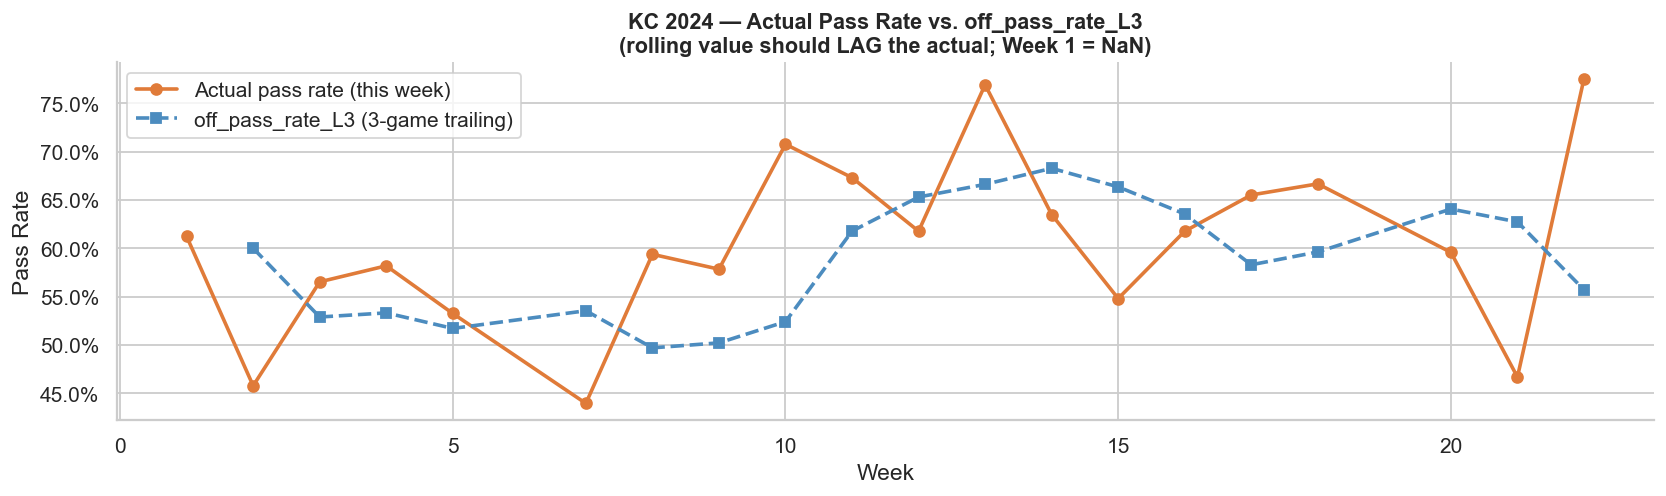

,actual_pass_rate,off_pass_rate_L3
week,,
1,0.612,NaN
2,0.458,0.600
3,0.565,0.529
4,0.582,0.533
5,0.532,0.517
7,0.439,0.535
8,0.594,0.497
9,0.578,0.502
10,0.708,0.524


In [3]:
# ── pick one team/season and trace off_pass_rate_L3 vs. actual pass rate ───
# off_pass_rate_L3 at week W should equal the pass rate from weeks W-3..W-1.
# We reconstruct the actual per-game pass rate for comparison.

TEAM, SEASON = "KC", 2024

team_plays = df[
    (df["posteam"] == TEAM) &
    (df["season"] == SEASON) &
    (df["play_type"].isin(["run", "pass"]))
].copy()

# actual pass rate per game-week
actual_rate = (
    team_plays.groupby("week")
    .apply(lambda g: (g["play_type"] == "pass").mean())
    .rename("actual_pass_rate")
)

# rolling feature value (should be the same for every play within a given week)
rolling_rate = (
    team_plays.groupby("week")["off_pass_rate_L3"]
    .first()
    .rename("off_pass_rate_L3")
)

check = pd.concat([actual_rate, rolling_rate], axis=1).reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(check["week"], check["actual_pass_rate"], marker="o", color=PASS_COLOR,
        linewidth=2, label="Actual pass rate (this week)")
ax.plot(check["week"], check["off_pass_rate_L3"], marker="s", color=RUN_COLOR,
        linewidth=2, linestyle="--", label="off_pass_rate_L3 (3-game trailing)")
ax.set_xlabel("Week")
ax.set_ylabel("Pass Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title(
    f"{TEAM} {SEASON} — Actual Pass Rate vs. off_pass_rate_L3\n"
    "(rolling value should LAG the actual; Week 1 = NaN)",
    fontsize=12, fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

display(check.set_index("week").round(3))

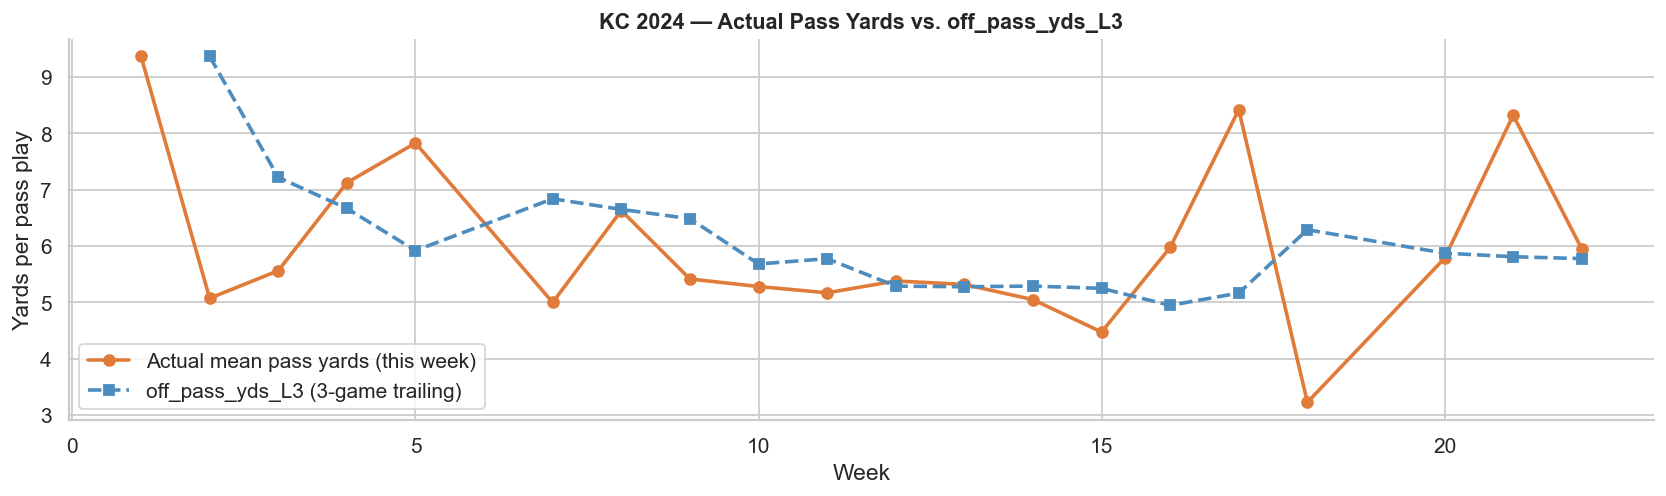

,actual_pass_yds,off_pass_yds_L3
week,,
1,9.37,NaN
2,5.07,9.37
3,5.56,7.22
4,7.12,6.67
5,7.83,5.92
7,5.00,6.84
8,6.63,6.65
9,5.42,6.49
10,5.28,5.68


In [4]:
# ── same check for off_pass_yds_L3 vs raw passing yards ────────────────────
# Reconstruct per-game mean passing yards (pass plays only) for this team
pass_yds_actual = (
    team_plays[team_plays["play_type"] == "pass"]
    .groupby("week")[TARGET]
    .mean()
    .rename("actual_pass_yds")
)
pass_yds_rolling = (
    team_plays.groupby("week")["off_pass_yds_L3"]
    .first()
    .rename("off_pass_yds_L3")
)
check2 = pd.concat([pass_yds_actual, pass_yds_rolling], axis=1).reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(check2["week"], check2["actual_pass_yds"], marker="o", color=PASS_COLOR,
        linewidth=2, label="Actual mean pass yards (this week)")
ax.plot(check2["week"], check2["off_pass_yds_L3"], marker="s", color=RUN_COLOR,
        linewidth=2, linestyle="--", label="off_pass_yds_L3 (3-game trailing)")
ax.set_xlabel("Week")
ax.set_ylabel("Yards per pass play")
ax.set_title(
    f"{TEAM} {SEASON} — Actual Pass Yards vs. off_pass_yds_L3",
    fontsize=12, fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

display(check2.set_index("week").round(2))

## 4. Value Sanity — Distributions & Outliers

Box plots to spot implausible ranges. Rolling averages should be smoother and more tightly bounded than single-game values.

In [5]:
# ── percentile table ───────────────────────────────────────────────────────
pct_table = (
    df[ROLLING_FEATURES]
    .astype(float)
    .quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .round(3)
)
pct_table.columns = [f"p{int(c*100)}" for c in pct_table.columns]
pct_table["range_p1_p99"] = (pct_table["p99"] - pct_table["p1"]).round(3)

display(
    pct_table.style
    .background_gradient(cmap="Blues", subset=["range_p1_p99"])
    .set_caption("Rolling Feature Percentile Summary (play-level)")
)

,p1,p5,p25,p50,p75,p95,p99,range_p1_p99
off_pass_rate_L3,0.386000,0.445000,0.526000,0.579000,0.627000,0.694000,0.738000,0.352000
off_rush_yds_L3,2.588000,3.129000,3.862000,4.391000,4.965000,5.962000,6.692000,4.104000
off_pass_yds_L3,3.466000,4.327000,5.482000,6.291000,7.191000,8.612000,9.795000,6.329000
off_epa_L3,-0.352000,-0.241000,-0.096000,-0.000000,0.091000,0.219000,0.301000,0.653000
off_rush_epa_L3,-0.424000,-0.280000,-0.123000,-0.032000,0.054000,0.184000,0.273000,0.697000
off_pass_epa_L3,-0.458000,-0.315000,-0.104000,0.037000,0.182000,0.393000,0.551000,1.009000
def_rush_yds_allowed_L3,2.598000,3.130000,3.874000,4.387000,4.943000,5.861000,6.655000,4.057000
def_pass_yds_allowed_L3,3.532000,4.375000,5.494000,6.281000,7.087000,8.420000,9.570000,6.038000
def_epa_L3,-0.350000,-0.230000,-0.099000,-0.006000,0.079000,0.200000,0.280000,0.630000
def_rush_epa_L3,-0.372000,-0.274000,-0.129000,-0.036000,0.046000,0.176000,0.278000,0.650000


## 5. Signal Strength — Incremental Correlation with `yards_gained`

How much does each **rolling** feature correlate with the target _beyond_ what the raw numeric features already explain?  
We compute both the raw Pearson r and the **partial correlation** after residualising on a small set of obvious confounders.

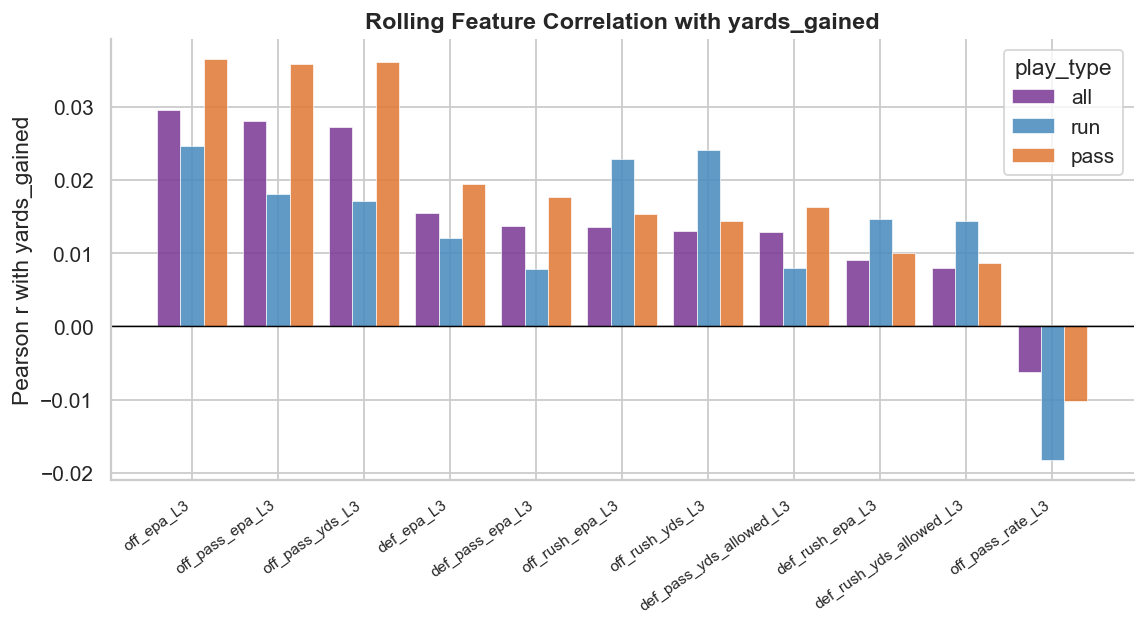

play_type,all,pass,run
feature,,,
off_epa_L3,0.0296,0.0365,0.0246
off_pass_epa_L3,0.0281,0.0358,0.0181
off_pass_yds_L3,0.0273,0.0361,0.0171
def_epa_L3,0.0155,0.0194,0.0121
def_pass_epa_L3,0.0137,0.0177,0.0079
off_rush_epa_L3,0.0136,0.0154,0.0229
off_rush_yds_L3,0.0130,0.0144,0.0241
def_pass_yds_allowed_L3,0.0129,0.0163,0.0080
def_rush_epa_L3,0.0090,0.0100,0.0147


In [6]:
# ── bivariate correlation: rolling features vs. target ─────────────────────
# Split by play type since the model will ultimately be run/pass aware.

rows = []
for feat in ROLLING_FEATURES:
    for pt in ["all", "run", "pass"]:
        sub = df if pt == "all" else df[df["play_type"] == pt]
        tmp = sub[[feat, TARGET]].astype(float).dropna()
        r = tmp[feat].corr(tmp[TARGET])
        rows.append({"feature": feat, "play_type": pt, "pearson_r": round(r, 4)})

corr_df = pd.DataFrame(rows)
pivot_r  = corr_df.pivot(index="feature", columns="play_type", values="pearson_r")
pivot_r["abs_all"] = pivot_r["all"].abs()
pivot_r = pivot_r.sort_values("abs_all", ascending=False).drop(columns="abs_all")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot_r))
width = 0.27
colors = {"all": "#7D3C98", "run": RUN_COLOR, "pass": PASS_COLOR}
for i, (col, color) in enumerate(colors.items()):
    ax.bar(x + (i - 1) * width, pivot_r[col], width=width,
           label=col, color=color, alpha=0.88, edgecolor="white", linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pivot_r.index, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Pearson r with yards_gained")
ax.set_title("Rolling Feature Correlation with yards_gained",
             fontsize=13, fontweight="bold")
ax.legend(title="play_type")
plt.tight_layout()
plt.show()

display(pivot_r.style
        .background_gradient(cmap="RdYlGn", vmin=-0.25, vmax=0.25)
        .format("{:.4f}")
        .set_caption("Pearson r with yards_gained by play type"))

## 6. Separability — Do Rolling Features Split Run vs. Pass?

A feature that separates run from pass is useful for **Stage 0** (the run/pass classifier).  
We measure this with Cohen's d (standardised mean difference) and an overlapping-density plot.

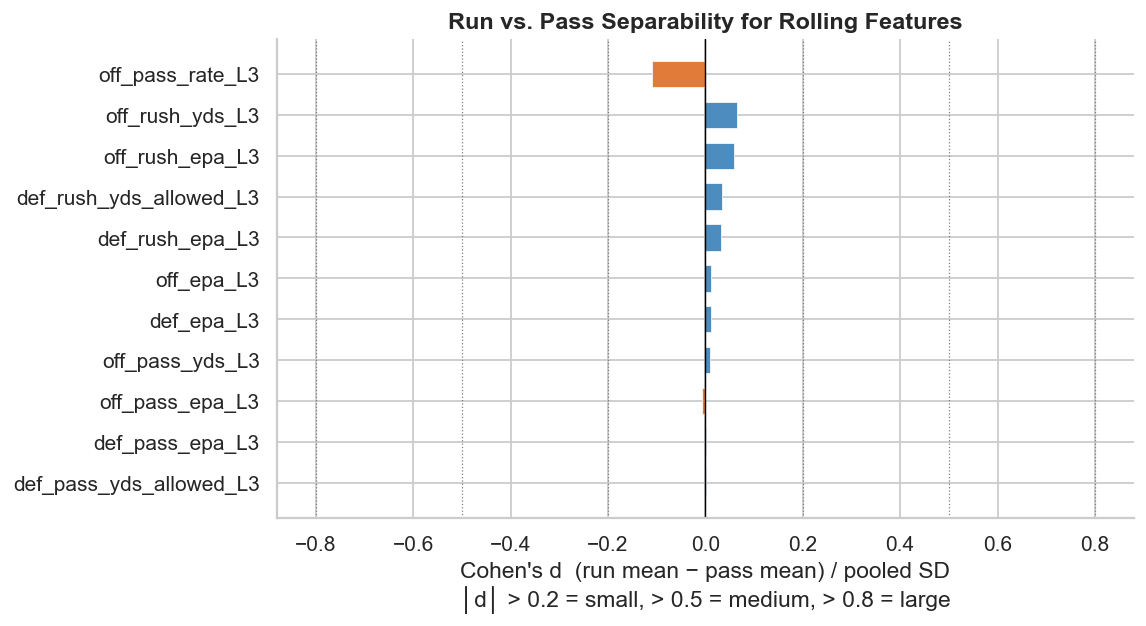

,feature,cohens_d,abs_d
0,off_pass_rate_L3,-0.1099,0.1099
1,off_rush_yds_L3,0.0641,0.0641
2,off_rush_epa_L3,0.0582,0.0582
3,def_rush_yds_allowed_L3,0.0340,0.0340
4,def_rush_epa_L3,0.0322,0.0322
5,off_epa_L3,0.0124,0.0124
6,def_epa_L3,0.0117,0.0117
7,off_pass_yds_L3,0.0085,0.0085
8,off_pass_epa_L3,-0.0071,0.0071
9,def_pass_epa_L3,0.0020,0.0020


In [7]:
# ── Cohen's d: run vs. pass for each rolling feature ──────────────────────
run_df  = df[df["play_type"] == "run"]
pass_df = df[df["play_type"] == "pass"]

def cohens_d(a, b):
    """Pooled-std Cohen's d."""
    a, b = a.dropna(), b.dropna()
    pooled_std = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

sep_rows = []
for feat in ROLLING_FEATURES:
    d = cohens_d(run_df[feat].astype(float), pass_df[feat].astype(float))
    sep_rows.append({"feature": feat, "cohens_d": round(d, 4),
                     "abs_d": round(abs(d), 4)})

sep_df = pd.DataFrame(sep_rows).sort_values("abs_d", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [RUN_COLOR if v >= 0 else PASS_COLOR for v in sep_df["cohens_d"]]
ax.barh(sep_df["feature"][::-1], sep_df["cohens_d"][::-1],
        color=bar_colors[::-1], edgecolor="white", linewidth=0.4, height=0.65)
ax.axvline(0, color="black", linewidth=0.8)
# Cohen's d benchmarks
for d_val, label in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
    for sign in [1, -1]:
        ax.axvline(sign * d_val, color="grey", linewidth=0.7, linestyle=":")
ax.set_xlabel("Cohen's d  (run mean − pass mean) / pooled SD\n"
              "│d│ > 0.2 = small, > 0.5 = medium, > 0.8 = large")
ax.set_title("Run vs. Pass Separability for Rolling Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

display(sep_df.style
        .background_gradient(cmap="RdYlGn", subset=["abs_d"], vmin=0, vmax=0.8)
        .format({"cohens_d": "{:.4f}", "abs_d": "{:.4f}"})
        .set_caption("Cohen's d — higher |d| = better run/pass separator"))

## 7. Collinearity — Among Engineered Features Only

High pairwise correlation between rolling features signals redundancy. We also flag VIF > 5 as worth monitoring.

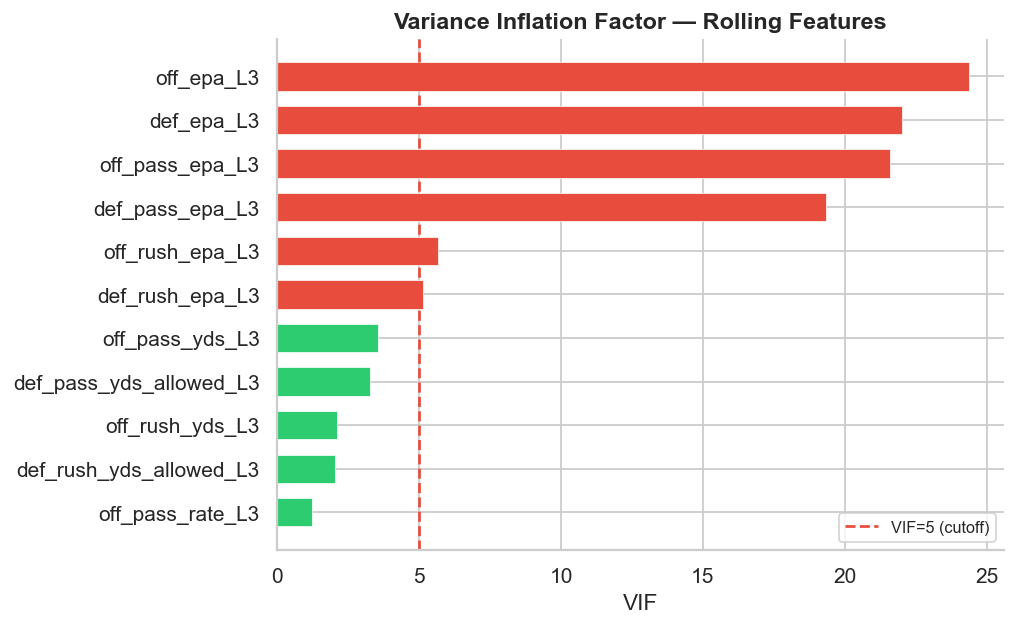

In [8]:
# ── VIF for rolling features ───────────────────────────────────────────────
from numpy.linalg import matrix_rank

def compute_vif(df_in, features):
    """Return a Series of VIF values for each feature."""
    tmp = df_in[features].astype(float).dropna()
    X = tmp.values
    vifs = {}
    for i, feat in enumerate(features):
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        X_others = np.column_stack([np.ones(len(y)), X_others])
        if matrix_rank(X_others) < X_others.shape[1]:
            vifs[feat] = np.nan
            continue
        coef, *_ = np.linalg.lstsq(X_others, y, rcond=None)
        y_hat = X_others @ coef
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vifs[feat] = round(1 / (1 - r2), 2) if r2 < 1 else np.inf
    return pd.Series(vifs, name="VIF").sort_values(ascending=False)

vif_series = compute_vif(df, ROLLING_FEATURES)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["#E74C3C" if v > 5 else "#2ECC71" for v in vif_series]
ax.barh(vif_series.index[::-1], vif_series.values[::-1],
        color=bar_colors[::-1], edgecolor="white", linewidth=0.4, height=0.65)
ax.axvline(5, color="#E74C3C", linewidth=1.5, linestyle="--", label="VIF=5 (cutoff)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor — Rolling Features",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Cross-Season Stability

Rolling feature distributions should remain stable across seasons. Dramatic drift indicates either data-pipeline changes or real-world NFL shifts (both worth knowing).

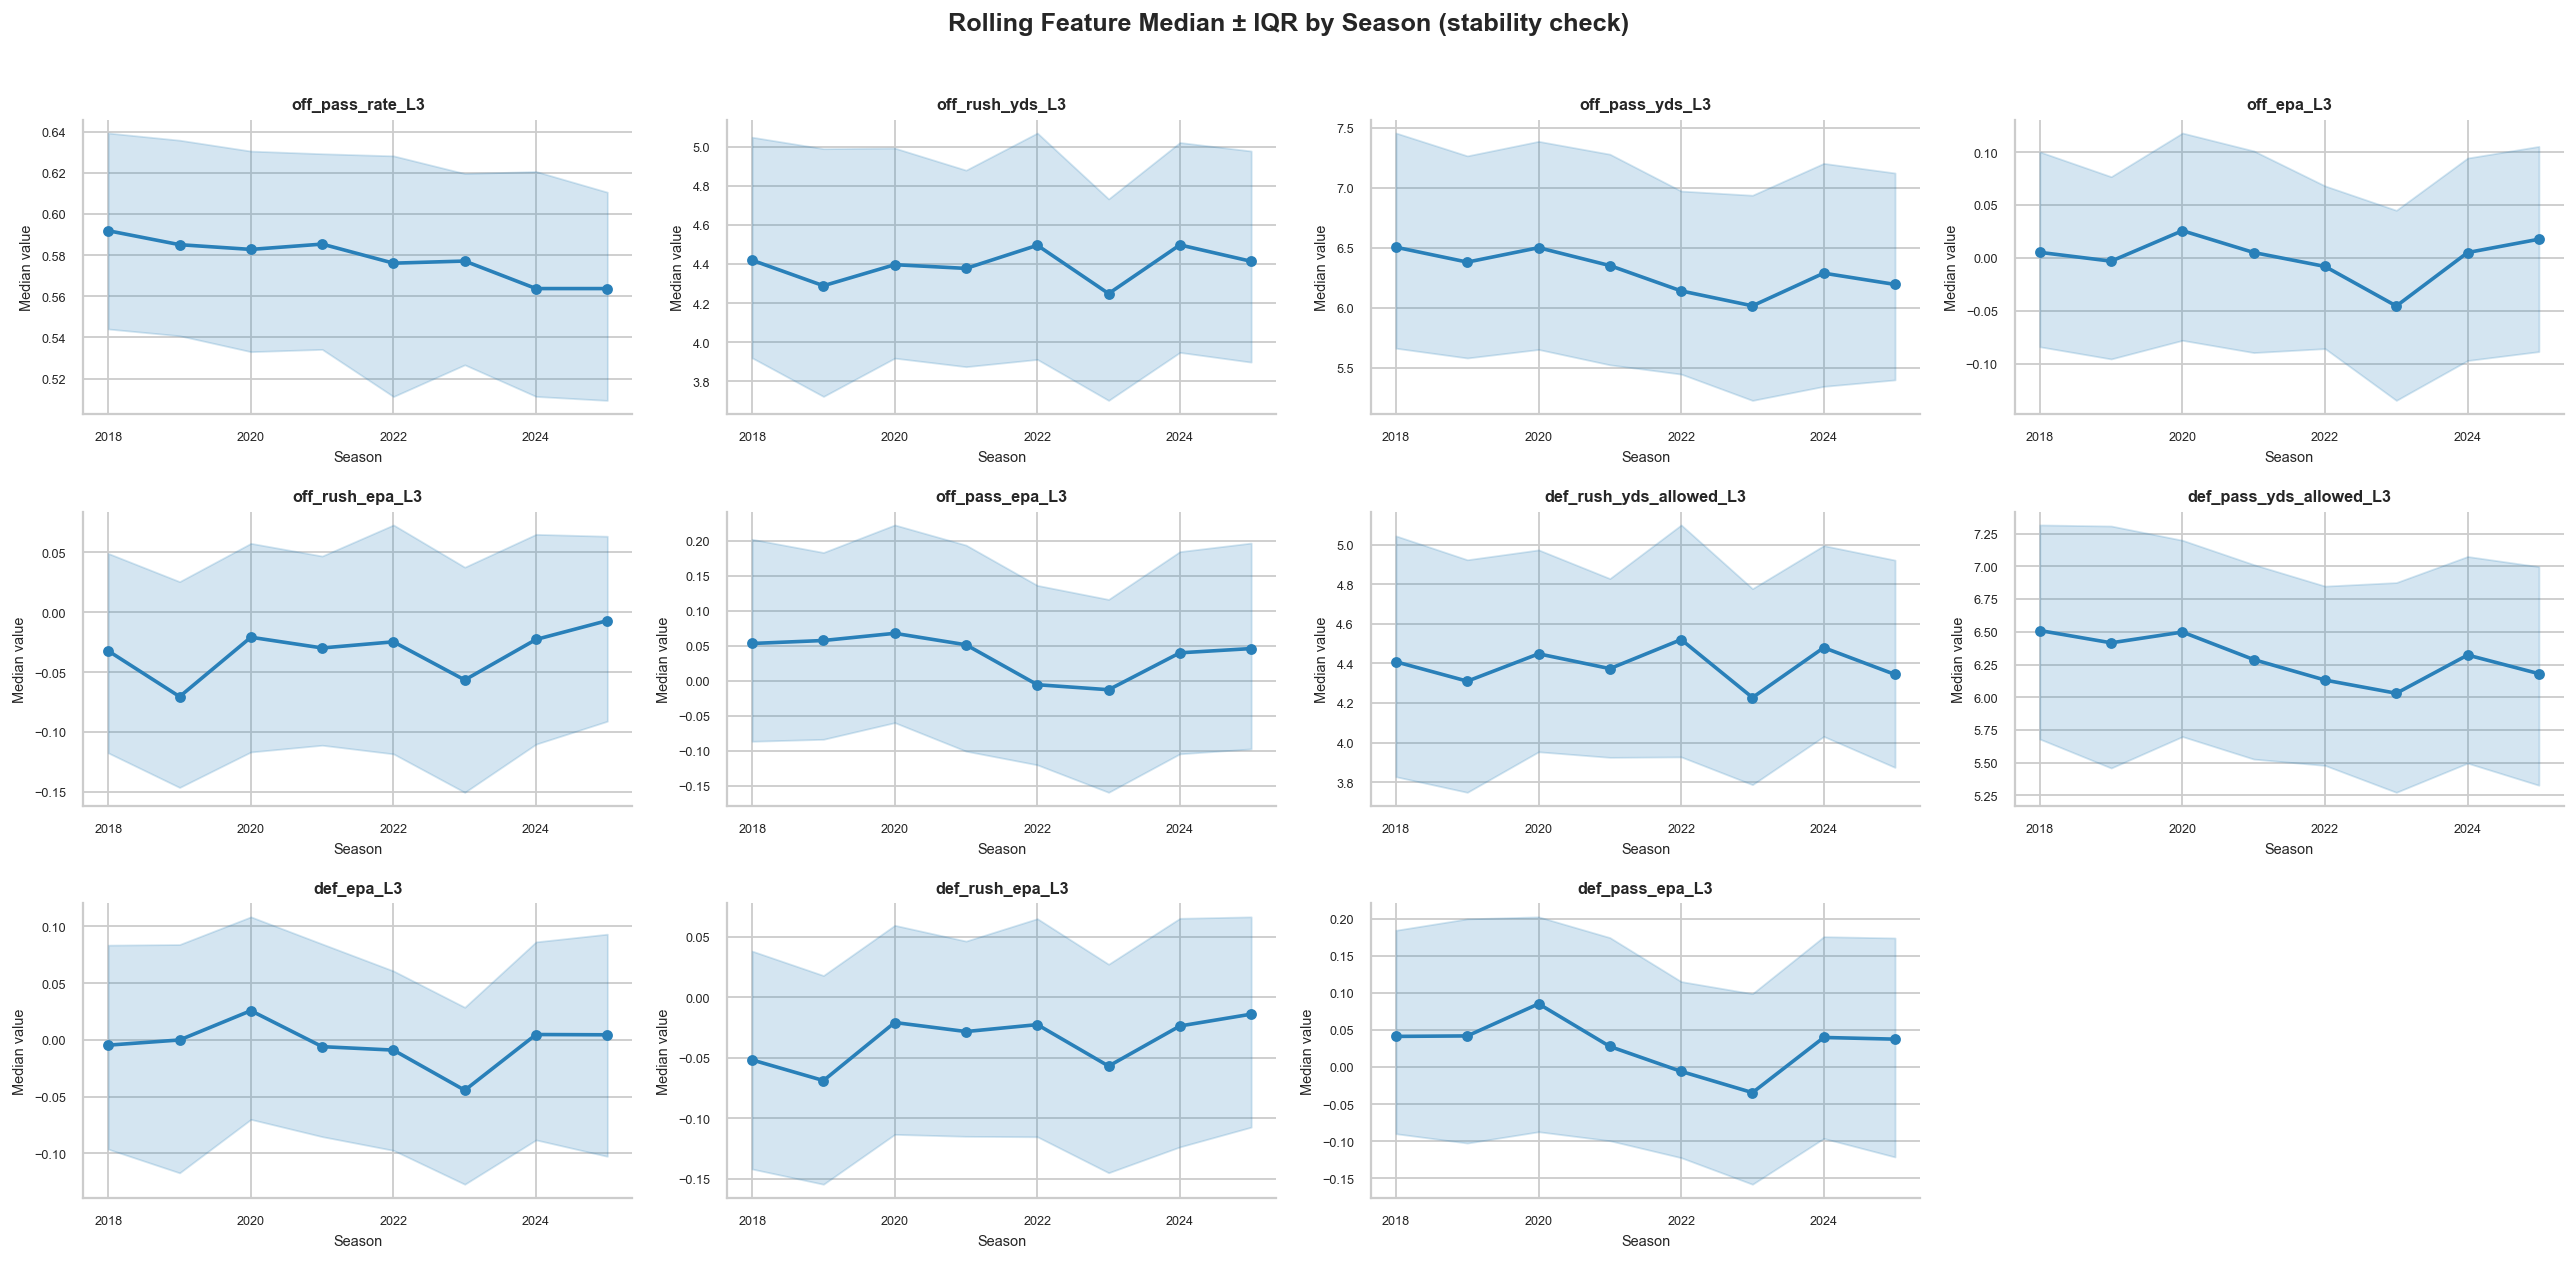

In [9]:
# ── median per feature per season ─────────────────────────────────────────
season_stats = (
    df.groupby("season")[ROLLING_FEATURES]
    .median()
    .astype(float)
)

ncols = 4
nrows = int(np.ceil(len(ROLLING_FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.2))
axes = axes.flatten()

for ax, feat in zip(axes, ROLLING_FEATURES):
    ax.plot(season_stats.index, season_stats[feat], marker="o",
            color="#2980B9", linewidth=2, markersize=5)
    ax.fill_between(
        season_stats.index,
        df.groupby("season")[feat].quantile(0.25).astype(float),
        df.groupby("season")[feat].quantile(0.75).astype(float),
        alpha=0.2, color="#2980B9", label="IQR",
    )
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_xlabel("Season", fontsize=8)
    ax.set_ylabel("Median value", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))

for ax in axes[len(ROLLING_FEATURES):]:
    ax.set_visible(False)

fig.suptitle("Rolling Feature Median ± IQR by Season (stability check)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

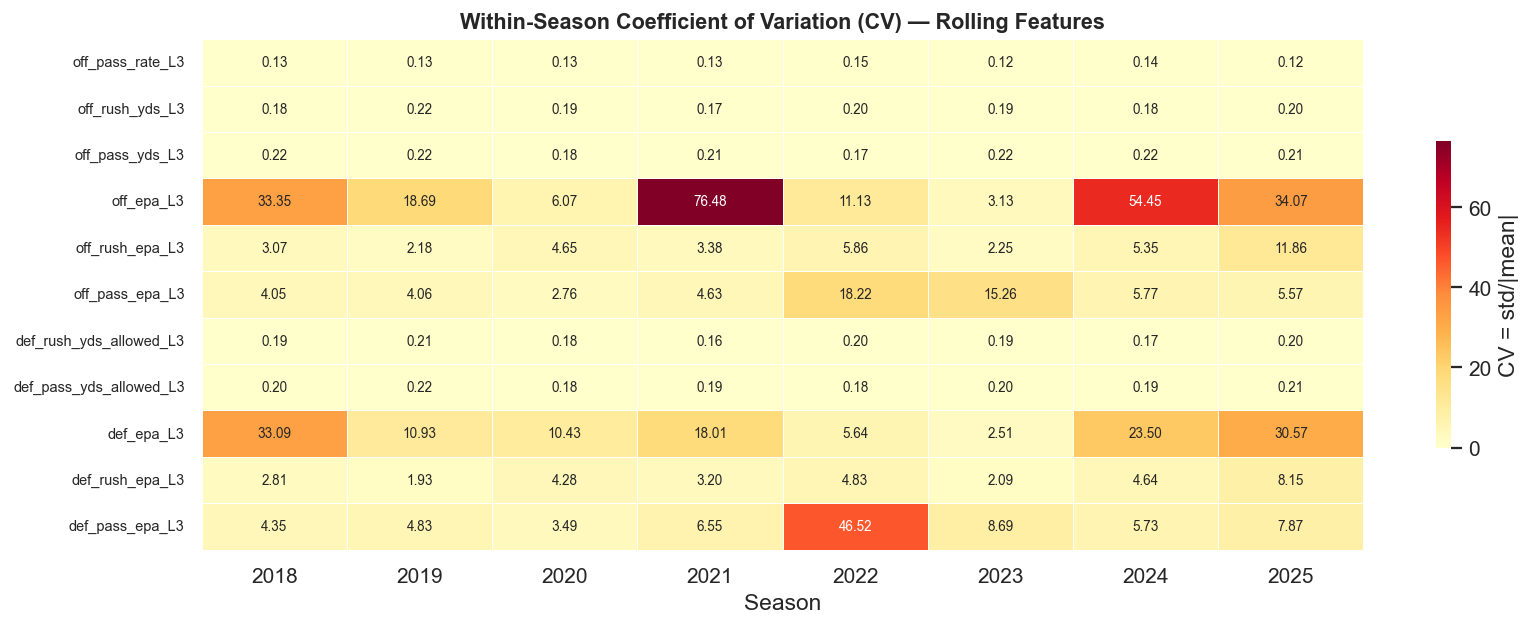

In [10]:
# ── coefficient of variation (CV) by season — flags unstable features ─────
season_cv = (
    df.groupby("season")[ROLLING_FEATURES]
    .std()
    .astype(float)
    /
    df.groupby("season")[ROLLING_FEATURES]
    .mean()
    .astype(float)
    .abs()
).round(3)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    season_cv.T,
    cmap="YlOrRd", vmin=0,
    annot=True, fmt=".2f", annot_kws={"size": 7.5},
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "CV = std/|mean|", "shrink": 0.6},
    ax=ax,
)
ax.set_xlabel("Season")
ax.set_title("Within-Season Coefficient of Variation (CV) — Rolling Features",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 9. Validation Summary

In [11]:
# ── one-row-per-feature validation scorecard ───────────────────────────────
scorecard_rows = []
for feat in ROLLING_FEATURES:
    vals        = df[feat].astype(float)
    null_pct    = vals.isnull().mean() * 100
    week1_null  = df[df["week"] == 1][feat].isnull().mean() * 100
    week2p_null = df[df["week"] > 1][feat].isnull().mean() * 100
    p1, p99     = vals.quantile(0.01), vals.quantile(0.99)
    corr_all    = vals.corr(df[TARGET].astype(float))
    vif_val     = vif_series.get(feat, np.nan)
    d_val       = sep_df.loc[sep_df["feature"] == feat, "abs_d"].values[0]

    scorecard_rows.append({
        "feature":         feat,
        "null_%":          round(null_pct, 2),
        "week1_null_%":    round(week1_null, 1),
        "week2+_null_%":   round(week2p_null, 2),
        "p1":              round(p1, 3),
        "p99":             round(p99, 3),
        "corr_target":     round(corr_all, 4),
        "VIF":             vif_val,
        "cohens_d (r/p)": d_val,
    })

scorecard = pd.DataFrame(scorecard_rows).set_index("feature")

display(
    scorecard.style
    .background_gradient(cmap="Reds",   subset=["week2+_null_%"])
    .background_gradient(cmap="RdYlGn", subset=["corr_target"],  vmin=-0.2, vmax=0.2)
    .background_gradient(cmap="RdYlGn_r", subset=["VIF"],        vmin=1, vmax=15)
    .background_gradient(cmap="Greens", subset=["cohens_d (r/p)"], vmin=0, vmax=0.8)
    .format({
        "null_%":           "{:.2f}%",
        "week1_null_%":     "{:.1f}%",
        "week2+_null_%":    "{:.2f}%",
        "corr_target":      "{:.4f}",
        "VIF":              "{:.2f}",
        "cohens_d (r/p)":   "{:.4f}",
    })
    .set_caption(
        "Feature Validation Scorecard — "
        "week2+_null should be ~0 | corr_target = signal | VIF = redundancy | cohens_d = run/pass separability"
    )
)

,null_%,week1_null_%,week2+_null_%,p1,p99,corr_target,VIF,cohens_d (r/p)
feature,,,,,,,,
off_pass_rate_L3,5.78%,100.0%,0.00%,0.386000,0.738000,-0.0063,1.24,0.1099
off_rush_yds_L3,5.78%,100.0%,0.00%,2.588000,6.692000,0.0130,2.12,0.0641
off_pass_yds_L3,5.78%,100.0%,0.00%,3.466000,9.795000,0.0273,3.55,0.0085
off_epa_L3,5.78%,100.0%,0.00%,-0.352000,0.301000,0.0296,24.38,0.0124
off_rush_epa_L3,5.78%,100.0%,0.00%,-0.424000,0.273000,0.0136,5.68,0.0582
off_pass_epa_L3,5.78%,100.0%,0.00%,-0.458000,0.551000,0.0281,21.59,0.0071
def_rush_yds_allowed_L3,5.78%,100.0%,0.00%,2.598000,6.655000,0.0080,2.03,0.0340
def_pass_yds_allowed_L3,5.78%,100.0%,0.00%,3.532000,9.570000,0.0129,3.27,0.0006
def_epa_L3,5.78%,100.0%,0.00%,-0.350000,0.280000,0.0155,22.01,0.0117
